# Features Engineering

# Comprehensive Predictive Maintenance Pipeline: Turbofan Engine Degradation Analysis

Predictive Maintenance (PdM) is the cornerstone of modern industrial operations, moving from reactive repairs to data-driven, proactive strategies. The core objective of this project is to develop a machine learning pipeline capable of predicting the Remaining Useful Life (RUL) of turbofan engines based on the NASA CMAPSS dataset.

### The Problem
Turbofan engines operate in extreme conditions, and their degradation is non-linear and complex. Raw sensor telemetry—such as temperature, pressure, and fan speed—contains high levels of noise and temporal dependencies that are difficult for standard algorithms to interpret directly.

### The Solution
Our pipeline addresses these challenges through a systematic, four-stage approach:
1. **Temporal Signal Processing:** Utilizing rolling window techniques to capture historical degradation trends rather than relying on point-in-time snapshots.
2. **Automated Feature Engineering:** Leveraging `tsfresh` to calculate complex statistical indicators (variance, entropy, frequency analysis) that reveal hidden failure signatures.
3. **Dimensionality Reduction:** Applying PCA to distill hundreds of features into the most critical information-carrying components, effectively overcoming the "curse of dimensionality."
4. **Predictive Analytics:** Establishing a robust Ridge Regression baseline to map these compressed feature vectors to the RUL, providing a clear, measurable metric for engine health.

By following this workflow, we bridge the gap between raw industrial data and actionable maintenance intelligence.

# 1. Environment Setup & Data Loading
In this section, we initialize the data science environment by importing essential libraries for data manipulation, mathematical computation, and visualization. We also load the CMAPSS dataset for both training and testing phases and establish the directory structure for saving project artefacts.

---

In [1]:
!pip install pandas==1.5.3 tsfresh==0.20.2

  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      Traceback (most recent call last):
        File "C:\Users\ka\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
        File "C:\Users\ka\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\ka\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 118, in get_requires_for_build_wheel
          return hook(config_settings)
                 ^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\ka\AppData\Local\Temp\pip-build-env-asquol7x\overlay\Lib\

## Imports & Global Config

In [1]:
# ── Standard ──────────────────────────────────────────────────────────────────
import os
import warnings
import pickle
from datetime import datetime
from pathlib import Path

# ── Numerical / Data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

# ── TSFresh ───────────────────────────────────────────────────────────────────
try:
    from tsfresh import extract_features, select_features
    from tsfresh.utilities.dataframe_functions import roll_time_series
    from tsfresh.feature_extraction import ComprehensiveFCParameters, MinimalFCParameters, EfficientFCParameters
    from tsfresh.feature_selection.relevance import calculate_relevance_table
    TSFRESH_AVAILABLE = True
    print('✅ TSFresh available')
except ImportError:
    TSFRESH_AVAILABLE = False
    print('⚠️  TSFresh not installed — run: pip install tsfresh')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print('All imports OK')
# ── CRITICAL: disable sklearn set_output API ─────────────────────────────────
# sklearn >= 1.2 wraps every TransformerMixin method with a set_output decorator
# that does boolean checks on DataFrames/Series → ValueError: ambiguous truth value
# This must be called BEFORE any tsfresh import or sklearn transformer usage.
from sklearn import set_config
set_config(transform_output='default')  # disable pandas output wrapping globally

import sklearn
print(f'sklearn version : {sklearn.__version__}')
print('set_output=default — sklearn wrapper disabled')

✅ TSFresh available
All imports OK
sklearn version : 1.9.0
set_output=default — sklearn wrapper disabled


## Load Data (self-contained, no utils.py)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING — works without any utils.py
# ─────────────────────────────────────────────────────────────────────────────

COLUMN_NAMES = (
    ['unit', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] +
    [f'sensor_{i}' for i in range(1, 22)]
)

SENSOR_COLS   = [c for c in COLUMN_NAMES if c.startswith('sensor_')]
SETTING_COLS  = ['setting_1', 'setting_2', 'setting_3']
FEATURE_COLS  = SETTING_COLS + SENSOR_COLS          # 24 raw features
RUL_UPPER_THRESHOLD = 125                           # piecewise-linear RUL cap
DATASET_ID    = 'FD001'


def find_data_path() -> str:
    """Search common locations for the CMAPSSData folder."""
    candidates = [
        'CMAPSSData',
        '../CMAPSSData',
        '../data/CMAPSSData',
        '../../data/CMAPSSData',
        'data/CMAPSSData',
    ]
    for rel in candidates:
        full = os.path.abspath(rel)
        if os.path.exists(os.path.join(full, f'train_{DATASET_ID}.txt')):
            print(f'✅ Data found at: {full}')
            return full + '/'
    raise FileNotFoundError(
        'CMAPSSData folder not found. '
        'Place it in the project root or adjust candidates list.'
    )


def read_dataset(name: str = 'FD001'):
    """Read train, test and RUL files; return three DataFrames."""
    path = find_data_path()
    read_kw = dict(sep=r'\s+', header=None, names=COLUMN_NAMES, engine='python')

    train = pd.read_csv(path + f'train_{name}.txt', **read_kw)
    test  = pd.read_csv(path + f'test_{name}.txt',  **read_kw)
    rul   = pd.read_csv(path + f'RUL_{name}.txt',   header=None, names=['rul'])
    rul['unit'] = range(1, len(rul) + 1)            # CRITICAL: add unit key
    return train, test, rul


def calculate_RUL(df: pd.DataFrame, upper_threshold: int = None) -> pd.Series:
    """Compute row-wise RUL; optionally apply piecewise-linear cap."""
    lifetime = df.groupby('unit')['time_cycles'].transform('max')
    rul = lifetime - df['time_cycles']
    if upper_threshold is not None:
        rul = rul.clip(upper=upper_threshold)
    return rul


# ── Load ──────────────────────────────────────────────────────────────────────
train_data, test_data, test_rul = read_dataset(DATASET_ID)
train_data['RUL'] = calculate_RUL(train_data, upper_threshold=RUL_UPPER_THRESHOLD)

print(f'\nTrain : {train_data.shape}   Test : {test_data.shape}   RUL file : {test_rul.shape}')
print(f'Engines — Train: {train_data.unit.nunique()}  Test: {test_data.unit.nunique()}')
train_data.head(3)

✅ Data found at: d:\DEPI\Project Git\Yaqza\ml\notebooks\CMAPSSData

Train : (20631, 27)   Test : (13096, 26)   RUL file : (100, 2)
Engines — Train: 100  Test: 100


,unit,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125


## Evaluation Metrics (CMAPSS asymmetric score + RMSE / MAE / MAPE)

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


def rul_score_f(err: float) -> float:
    """Single-sample asymmetric CMAPSS penalty."""
    return np.exp(err / 10) - 1 if err >= 0 else np.exp(-err / 13) - 1


def rul_score(true_rul, estimated_rul) -> float:
    """Aggregate asymmetric CMAPSS score (lower = better)."""
    errs = np.asarray(estimated_rul) - np.asarray(true_rul)
    return float(np.sum([rul_score_f(e) for e in errs]))


def mape(true_rul, estimated_rul) -> float:
    t = np.asarray(true_rul, dtype=float)
    mask = t != 0
    return float(np.mean(np.abs((t[mask] - np.asarray(estimated_rul)[mask]) / t[mask])) * 100)


SCORE_FUNCTIONS = {
    'rmse':  lambda t, p: float(np.sqrt(mean_squared_error(t, p))),
    'mae':   lambda t, p: float(mean_absolute_error(t, p)),
    'mape':  mape,
    'score': rul_score,
}


def evaluate_model(model, X, true_rul, metrics='all', label='Model') -> dict:
    """Predict with *model*, compute chosen metrics, print a tidy table."""
    pred_rul = model.predict(X)
    keys = list(SCORE_FUNCTIONS) if metrics == 'all' else (
        [metrics] if isinstance(metrics, str) else list(metrics)
    )
    results = {k: SCORE_FUNCTIONS[k](true_rul, pred_rul) for k in keys}
    print(f'\n── {label} ──')
    for k, v in results.items():
        print(f'  {k.upper():6s}: {v:.4f}')
    return results


print('✅ Evaluation metrics ready')

✅ Evaluation metrics ready


## Feature Selection: Low-Variance Remover

In [4]:
class LowVarianceFeaturesRemover(BaseEstimator, TransformerMixin):
    """
    Drops columns whose variance across the *training* data falls below
    `threshold`.  Uses sklearn VarianceThreshold under the hood but
    returns a DataFrame with named columns preserved.
    """

    def __init__(self, threshold: float = 0.01):
        self.threshold = threshold

    def fit(self, X: pd.DataFrame, y=None):          # y=None — Pipeline compat
        self._selector = VarianceThreshold(threshold=self.threshold)
        self._selector.fit(X)
        self.kept_columns_   = X.columns[self._selector.get_support()].tolist()
        self.dropped_columns_ = [
            c for c in X.columns if c not in self.kept_columns_
        ]
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X[self.kept_columns_]

    def fit_transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.fit(X, y).transform(X)


# ── Apply on raw feature columns ──────────────────────────────────────────────
lvr = LowVarianceFeaturesRemover(threshold=0.01)
train_features_raw = train_data[FEATURE_COLS]

lvr.fit(train_features_raw)

print(f'Original features : {len(FEATURE_COLS)}')
print(f'Dropped (low var) : {len(lvr.dropped_columns_)} → {lvr.dropped_columns_}')
print(f'Kept              : {len(lvr.kept_columns_)} → {lvr.kept_columns_}')

SELECTED_FEATURES = lvr.kept_columns_   # ← used in all downstream cells

# Apply to both sets
train_selected = lvr.transform(train_data[FEATURE_COLS])
test_selected  = lvr.transform(test_data[FEATURE_COLS])

print(f'\nTrain selected shape: {train_selected.shape}')
print(f'Test  selected shape: {test_selected.shape}')

Original features : 24
Dropped (low var) : 13 → ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']
Kept              : 11 → ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']

Train selected shape: (20631, 11)
Test  selected shape: (13096, 11)


## Correlation Analysis & Sensor Heatmap

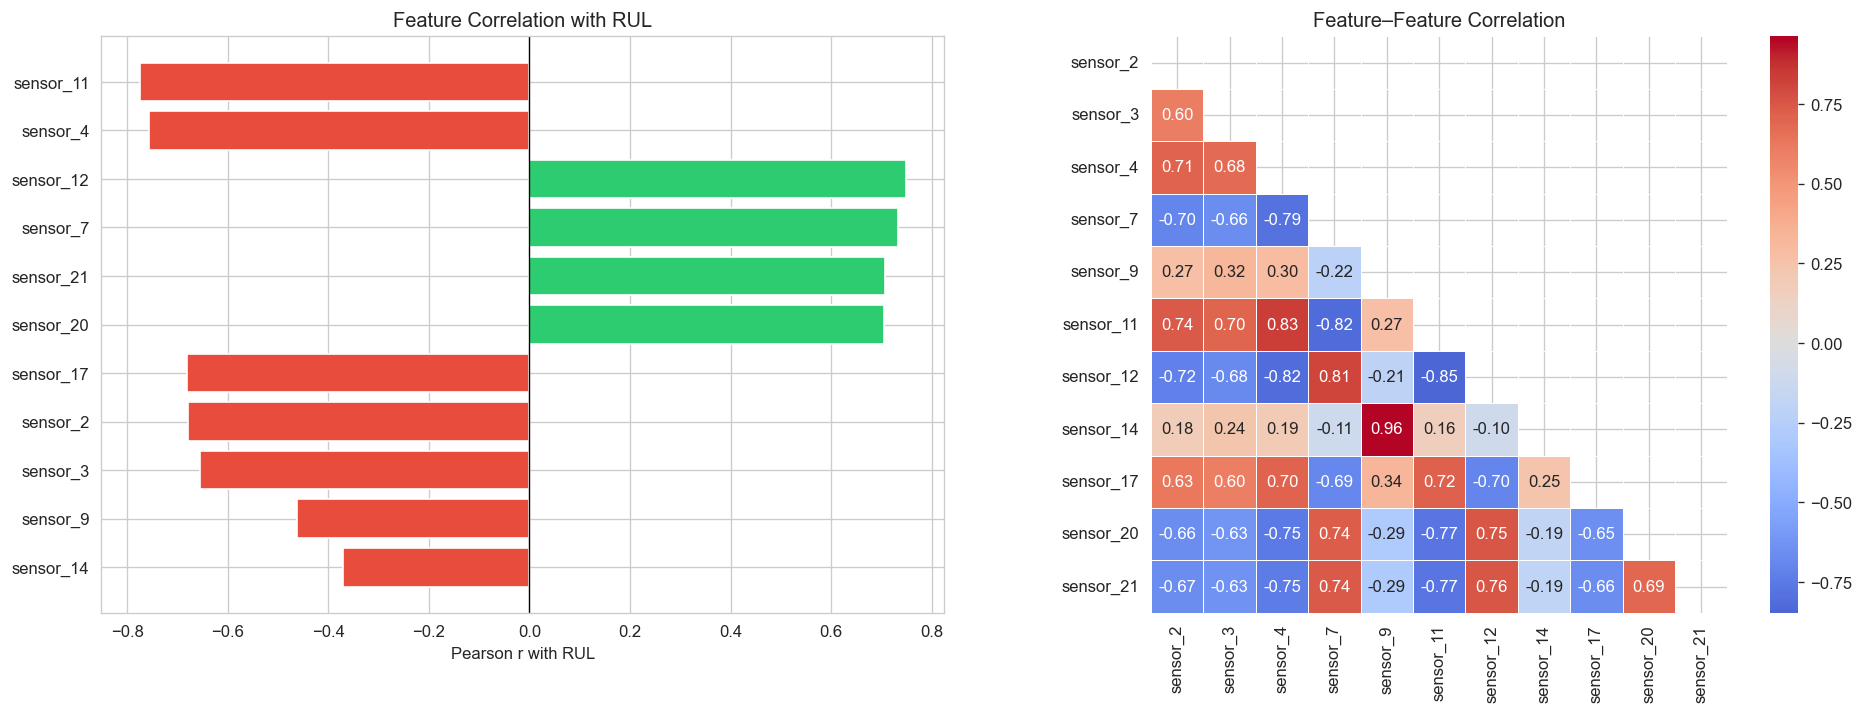


Top 5 positively correlated:
           correlation_with_RUL
sensor_12              0.748870
sensor_7               0.733021
sensor_21              0.707334
sensor_20              0.704626

Top 5 negatively correlated:
           correlation_with_RUL
sensor_11             -0.775230
sensor_4              -0.757157
sensor_17             -0.680829
sensor_2              -0.678458
sensor_3              -0.655030


In [5]:
# ── Correlation with RUL ───────────────────────────────────────────────────────
corr_df = (
    train_data[SELECTED_FEATURES + ['RUL']]
    .corr()['RUL']
    .drop('RUL')
    .sort_values(key=abs, ascending=False)
    .to_frame()
)
corr_df.columns = ['correlation_with_RUL']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_df['correlation_with_RUL']]
axes[0].barh(corr_df.index, corr_df['correlation_with_RUL'], color=colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Pearson r with RUL')
axes[0].set_title('Feature Correlation with RUL')
axes[0].invert_yaxis()

# Feature–feature heatmap
corr_matrix = train_data[SELECTED_FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[1],
    cmap='coolwarm', center=0, linewidths=0.3,
    annot=len(SELECTED_FEATURES) <= 14,
    fmt='.2f', square=True
)
axes[1].set_title('Feature–Feature Correlation')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_analysis.png', bbox_inches='tight')
plt.show()

print('\nTop 5 positively correlated:')
print(corr_df[corr_df['correlation_with_RUL'] > 0].head())
print('\nTop 5 negatively correlated:')
print(corr_df[corr_df['correlation_with_RUL'] < 0].head())

---

## Normalization (MinMaxScaler, returns DataFrame)

In [6]:
class DataFrameMinMaxScaler(BaseEstimator, TransformerMixin):
    """
    MinMaxScaler wrapper that preserves DataFrame column names and index.
    fit() is on training data only; transform() safely reindexes to stored columns.
    """

    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range

    def fit(self, X: pd.DataFrame, y=None):
        self.columns_ = X.columns.tolist()
        self._scaler  = MinMaxScaler(feature_range=self.feature_range)
        self._scaler.fit(X.values)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_arr = X[self.columns_].values          # enforce column order
        return pd.DataFrame(
            self._scaler.transform(X_arr),
            columns=self.columns_,
            index=X.index
        )

    def inverse_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return pd.DataFrame(
            self._scaler.inverse_transform(X.values),
            columns=self.columns_,
            index=X.index
        )


# ── Fit on TRAIN selected features, apply to both ─────────────────────────────
scaler = DataFrameMinMaxScaler()
scaler.fit(train_selected)

train_scaled = scaler.transform(train_selected)
test_scaled  = scaler.transform(test_selected)

# Re-attach metadata columns (unit, time_cycles, RUL)
train_scaled.insert(0, 'time_cycles', train_data['time_cycles'].values)
train_scaled.insert(0, 'unit',        train_data['unit'].values)
train_scaled['RUL'] = train_data['RUL'].values

test_scaled.insert(0, 'time_cycles', test_data['time_cycles'].values)
test_scaled.insert(0, 'unit',        test_data['unit'].values)

print(f'Train scaled : {train_scaled.shape}')
print(f'Test  scaled : {test_scaled.shape}')

# Verify range
feat_only = train_scaled[SELECTED_FEATURES]
print(f'Feature min: {feat_only.values.min():.4f}  max: {feat_only.values.max():.4f}')
train_scaled.head(3)

Train scaled : (20631, 14)
Test  scaled : (13096, 13)
Feature min: 0.0000  max: 1.0000


,unit,time_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_14,sensor_17,sensor_20,sensor_21,RUL
0,1,1,0.183735,0.406802,0.309757,0.726248,0.109755,0.369048,0.633262,0.199608,0.333333,0.713178,0.724662,125
1,1,2,0.283133,0.453019,0.352633,0.628019,0.100242,0.380952,0.765458,0.162813,0.333333,0.666667,0.731014,125
2,1,3,0.343373,0.369523,0.370527,0.710145,0.140043,0.250000,0.795309,0.171793,0.166667,0.627907,0.621375,125


## Windowing / Sequence Generation

In [7]:
class SlidingWindowTransformer(BaseEstimator, TransformerMixin):
    """
    Converts per-cycle tabular data into rolling-window sequences.

    For each engine and each cycle t, assembles a window of the last
    `window_size` cycles of feature data (padded with zeros if t < window_size).

    Returns
    -------
    X_seq   : np.ndarray  shape (N, window_size, n_features)
    meta_df : pd.DataFrame with ['unit', 'time_cycles', 'RUL'] if RUL present
    """

    def __init__(self, window_size: int = 30, feature_cols: list = None):
        self.window_size  = window_size
        self.feature_cols = feature_cols

    def fit(self, X: pd.DataFrame, y=None):
        self.feature_cols_ = self.feature_cols or [
            c for c in X.columns
            if c not in ('unit', 'time_cycles', 'RUL')
        ]
        return self

    def transform(self, X: pd.DataFrame):
        sequences, meta = [], []
        for unit_id, grp in X.groupby('unit', sort=True):
            grp = grp.sort_values('time_cycles').reset_index(drop=True)
            arr = grp[self.feature_cols_].values     # (T, F)
            T   = len(arr)
            for t in range(T):
                start = t - self.window_size + 1
                if start < 0:
                    # zero-pad beginning
                    pad = np.zeros((-start, arr.shape[1]))
                    window = np.vstack([pad, arr[:t + 1]])
                else:
                    window = arr[start: t + 1]
                sequences.append(window)
                row = {'unit': unit_id,
                       'time_cycles': grp.loc[t, 'time_cycles']}
                if 'RUL' in grp.columns:
                    row['RUL'] = grp.loc[t, 'RUL']
                meta.append(row)

        X_seq   = np.stack(sequences, axis=0)   # (N, W, F)
        meta_df = pd.DataFrame(meta).reset_index(drop=True)
        return X_seq, meta_df


WINDOW_SIZE = 30

window_tf = SlidingWindowTransformer(
    window_size  = WINDOW_SIZE,
    feature_cols = SELECTED_FEATURES
)
window_tf.fit(train_scaled)

X_train_seq, meta_train = window_tf.transform(train_scaled)
X_test_seq,  meta_test  = window_tf.transform(test_scaled)

y_train = meta_train['RUL'].values

print(f'Train sequences : {X_train_seq.shape}  →  (samples, window, features)')
print(f'Test  sequences : {X_test_seq.shape}')
print(f'y_train RUL     : {y_train.shape}  min={y_train.min():.0f}  max={y_train.max():.0f}')

Train sequences : (20631, 30, 11)  →  (samples, window, features)
Test  sequences : (13096, 30, 11)
y_train RUL     : (20631,)  min=0  max=125


## Save Preprocessed Data

In [8]:
def save_pickle(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  ✅ Saved: {path}')


print('Saving preprocessed artefacts ...')

save_pickle(train_scaled,    OUTPUT_DIR / 'train_scaled.pkl')
save_pickle(test_scaled,     OUTPUT_DIR / 'test_scaled.pkl')
save_pickle(X_train_seq,     OUTPUT_DIR / 'X_train_seq.npy')
save_pickle(X_test_seq,      OUTPUT_DIR / 'X_test_seq.npy')
save_pickle(y_train,         OUTPUT_DIR / 'y_train.npy')
save_pickle(meta_train,      OUTPUT_DIR / 'meta_train.pkl')
save_pickle(meta_test,       OUTPUT_DIR / 'meta_test.pkl')
save_pickle(scaler,          OUTPUT_DIR / 'scaler.pkl')
save_pickle(lvr,             OUTPUT_DIR / 'lvr.pkl')
save_pickle(SELECTED_FEATURES, OUTPUT_DIR / 'selected_features.pkl')

# Also save as numpy arrays for non-pickle consumers
np.save(OUTPUT_DIR / 'X_train_seq.npy', X_train_seq)
np.save(OUTPUT_DIR / 'X_test_seq.npy',  X_test_seq)
np.save(OUTPUT_DIR / 'y_train.npy',     y_train)

print('\nAll artefacts saved to:', OUTPUT_DIR.resolve())

Saving preprocessed artefacts ...
  ✅ Saved: outputs\train_scaled.pkl
  ✅ Saved: outputs\test_scaled.pkl
  ✅ Saved: outputs\X_train_seq.npy
  ✅ Saved: outputs\X_test_seq.npy
  ✅ Saved: outputs\y_train.npy
  ✅ Saved: outputs\meta_train.pkl
  ✅ Saved: outputs\meta_test.pkl
  ✅ Saved: outputs\scaler.pkl
  ✅ Saved: outputs\lvr.pkl
  ✅ Saved: outputs\selected_features.pkl

All artefacts saved to: D:\DEPI\Project Git\Yaqza\ml\notebooks\outputs


# 2. Custom Pipeline Architecture & Class Definitions
In this module, we move away from procedural scripts towards an Object-Oriented Pipeline. By defining custom classes that inherit from Scikit-Learn's `BaseEstimator` and `TransformerMixin`, we treat our preprocessing steps as first-class components. 

- **Why?** This approach ensures that we can treat the entire extraction, selection, and reduction process as a single, immutable object. It solves the issue of code repeatability—we write the logic once, and it remains consistent across the Training and Testing datasets, eliminating the risk of mismatched transformations.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from datetime import datetime
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import roll_time_series
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.feature_extraction import MinimalFCParameters

# ─── 9a RollTimeSeries Wrapper ───────────────────────────────────────
class RollTimeSeriesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_size: int = 30, min_timeshift: int = 0):
        self.window_size   = window_size
        self.min_timeshift = min_timeshift

    def fit(self, X: pd.DataFrame, y=None):
        self.feature_cols_ = [
            c for c in X.columns if c not in ('unit', 'time_cycles', 'RUL')
        ]
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        cols = ['unit', 'time_cycles'] + self.feature_cols_
        X_in = X[cols].copy().reset_index(drop=True)
        rolled = roll_time_series(
            X_in,
            column_id='unit',
            column_sort='time_cycles',
            max_timeshift=self.window_size,
            min_timeshift=self.min_timeshift,
            n_jobs=0,
        )
        rolled = rolled.drop(columns=['unit'])
        print(f'  Rolled shape: {rolled.shape}')
        return rolled

# ─── 9b TSFresh Feature Extractor ────────────────────────────────────
def _safe_extract_features(X_rolled, calc):
    import warnings as _warnings_mod
    _orig_simplefilter = _warnings_mod.simplefilter
    _warnings_mod.simplefilter = lambda *a, **kw: None
    try:
        result = extract_features(
            X_rolled,
            column_id='id',
            column_sort='time_cycles',
            default_fc_parameters=calc,
            n_jobs=0,
            show_warnings=False,
            disable_progressbar=False,
        )
    finally:
        _warnings_mod.simplefilter = _orig_simplefilter
    return result

class TSFreshFeaturesExtractor:
    def __init__(self, calc=None):
        self.calc = calc or MinimalFCParameters()

    def fit(self, X=None, y=None):
        return self

    def _clean_features(self, X: pd.DataFrame) -> pd.DataFrame:
        old = X.shape[1]
        X = X.loc[:, ~X.columns.duplicated()]
        print(f'    Dropped {old - X.shape[1]} duplicate columns')

        old = X.shape[1]
        X = X.dropna(axis=1, how='all')
        print(f'    Dropped {old - X.shape[1]} all-NaN columns')

        na_count = int(X.isna().sum().sum())
        if na_count:
            print(f'    Filling {na_count} NaN → 0')
            X = X.fillna(0)

        old = X.shape[1]
        X = X.loc[:, X.std() > 0]
        print(f'    Dropped {old - X.shape[1]} constant columns')
        return X

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        start = datetime.now()
        print('  Extracting TSFresh features ...')
        X_feat = _safe_extract_features(X, self.calc)
        print(f'  Done {datetime.now() - start} — raw: {X_feat.shape}')
        X_feat = self._clean_features(X_feat)
        print(f'  Clean shape: {X_feat.shape}')
        return X_feat

    def fit_transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.transform(X)

# ─── 9c TSFresh Feature Selector ─────────────────────────────────────
class TSFreshFeaturesSelector:
    def __init__(self, fdr_level: float = 0.05):
        self.fdr_level = fdr_level

    def fit(self, X: pd.DataFrame, y=None):
        if y is None:
            self.relevant_features_ = X.columns.tolist()
            return self
        y_s = pd.Series(np.asarray(y, dtype=float), index=X.index)
        rel = calculate_relevance_table(X, y_s, fdr_level=self.fdr_level)
        self.relevant_features_ = rel[rel['relevant']].index.tolist()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        cols = [c for c in self.relevant_features_ if c in X.columns]
        return X[cols]

    def fit_transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.fit(X, y=y).transform(X)

# ─── 9d Custom PCA ───────────────────────────────────────────────────
class CustomPCA:
    def __init__(self, n_components=None, random_state: int = 42,
                 explained_variance_target: float = None):
        self.n_components              = n_components
        self.random_state              = random_state
        self.explained_variance_target = explained_variance_target

    def fit(self, X: pd.DataFrame, y=None):
        self.fit_columns_ = X.columns.tolist()
        self.scaler_      = StandardScaler()
        X_sc = self.scaler_.fit_transform(X[self.fit_columns_].values)
        self.pca_ = PCA(
            n_components=self.n_components,
            random_state=self.random_state
        ).fit(X_sc)
        if self.explained_variance_target is not None:
            cum = np.cumsum(self.pca_.explained_variance_ratio_)
            self.n_selected_ = int(
                np.searchsorted(cum, self.explained_variance_target) + 1
            )
        else:
            self.n_selected_ = self.pca_.n_components_
        ev = self.pca_.explained_variance_ratio_[:self.n_selected_].sum()
        print(f'  PCA: {self.n_selected_} components ({ev*100:.1f}% variance)')
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_aligned = X.reindex(columns=self.fit_columns_, fill_value=0)
        X_sc      = self.scaler_.transform(X_aligned.values)
        X_pca     = self.pca_.transform(X_sc)[:, :self.n_selected_]
        return pd.DataFrame(
            X_pca,
            columns=[f'PC{i+1}' for i in range(X_pca.shape[1])],
            index=X.index
        )

    def fit_transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.fit(X).transform(X)

# 3. Hyper-parameter Strategy & Operational Configuration
Here, we initialize the architectural parameters. Key variables, such as `ROLL_WINDOW` and the number of PCA components, are defined here. We follow a "Centralized Configuration" pattern; instead of hard-coding values inside functions, we define them in this cell. This allows us to perform rapid sensitivity analysis (tuning the model) by changing only one variable, making our experiments highly reproducible and systematic.

In [15]:
if not TSFRESH_AVAILABLE:
    raise RuntimeError('TSFresh is required — install with: pip install tsfresh')

# Choose feature-calculation complexity:
#   MinimalFCParameters()      → fast, ~10 features/sensor   (good for testing)
#   EfficientFCParameters()    → balanced, ~100 features/sensor
#   ComprehensiveFCParameters() → full, ~800 features/sensor  (slow)
FC_PARAMS = MinimalFCParameters()     # ← change here for richer features
ROLL_WINDOW = 30                      # must match WINDOW_SIZE above
PCA_VAR_TARGET = 0.95                 # keep PCs that cover 95% variance

tsfresh_pipeline = Pipeline([
    ('roller',    RollTimeSeriesTransformer(window_size=ROLL_WINDOW)),
    ('extractor', TSFreshFeaturesExtractor(calc=FC_PARAMS)),
    # selector is applied manually after fit so we can pass y
])

pca_step = CustomPCA(
    n_components=None,
    explained_variance_target=PCA_VAR_TARGET,
    random_state=RANDOM_STATE
)

selector = TSFreshFeaturesSelector(fdr_level=0.05)

print(f'TSFresh pipeline ready')
print(f'  FC params   : {type(FC_PARAMS).__name__}')
print(f'  Roll window : {ROLL_WINDOW} cycles')
print(f'  PCA target  : {PCA_VAR_TARGET * 100:.0f}% variance')

TSFresh pipeline ready
  FC params   : MinimalFCParameters
  Roll window : 30 cycles
  PCA target  : 95% variance


# 4. Deep Feature Extraction (Training Phase)
This is the "Engine Room" of our pipeline. We are transforming raw, univariate sensor streams into a multi-dimensional feature space. 
- **The Rolling Window:** By sliding a window over the time-series data, we allow the model to see the "history" of the engine, which is vital for detecting gradual degradation.
- **TSFresh Extraction:** We extract comprehensive statistical features (like kurtosis, skewness, and spectral energy). 
- **Data Cleaning:** Real-world data is messy. We perform rigorous cleaning, including the removal of features with zero variance (constant features) and imputation of NaNs. This ensures that the downstream algorithms are not biased by faulty or non-informative sensor telemetry.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Runtime: ~2-5 min (Minimal) | 10-30 min (Efficient) | 60+ min (Comprehensive)
# Each step called EXPLICITLY — no sklearn Pipeline, no fit_transform.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('STEP 1a — Roll time series (train)')
print('=' * 60)
_t0 = datetime.now()

# Instantiate
roller    = RollTimeSeriesTransformer(window_size=ROLL_WINDOW)
extractor = TSFreshFeaturesExtractor(calc=FC_PARAMS)   # plain class

# Roll
roller.fit(train_scaled)                               # saves feature_cols_
X_rolled = roller.transform(train_scaled)              # no y involved

print(f'\n{"=" * 60}')
print('STEP 1b — Extract TSFresh features')
print('=' * 60)

# Extract — call transform() directly, NOT fit_transform()
# extractor.fit() is a no-op but called for API consistency
extractor.fit(X_rolled)                                # no-op, no y
X_tsfresh_train = extractor.transform(X_rolled)        # pure transform, no y

print(f'\n{"=" * 60}')
print('STEP 1c — Align RUL labels to extracted index')
print('=' * 60)

# tsfresh sets index to MultiIndex (unit, anchor_cycle)
index_df = X_tsfresh_train.index.to_frame(index=False)
index_df.columns = ['unit', 'anchor_cycle']

rul_lookup = (
    train_scaled[['unit', 'time_cycles', 'RUL']]
    .rename(columns={'time_cycles': 'anchor_cycle'})
    .drop_duplicates()
)

merged = index_df.merge(rul_lookup, on=['unit', 'anchor_cycle'], how='left')
y_tsfresh_train = merged['RUL'].to_numpy(dtype=float)  # plain numpy, no Series

print(f'TSFresh features     : {X_tsfresh_train.shape}')
print(f'y_tsfresh_train      : {y_tsfresh_train.shape}')
print(f'NaN in y             : {int(np.isnan(y_tsfresh_train).sum())}')

# Drop unmatched rows (rolling window edges)
valid_mask = ~np.isnan(y_tsfresh_train)
X_tsfresh_train = X_tsfresh_train[valid_mask]
y_tsfresh_train = y_tsfresh_train[valid_mask]

print(f'After NaN-label drop : {X_tsfresh_train.shape}')
print(f'Total time           : {datetime.now() - _t0}')

STEP 1a — Roll time series (train)


Rolling:   0%|          | 0/362 [00:00<?, ?it/s]

Rolling: 100%|██████████| 362/362 [00:18<00:00, 19.78it/s] 


  Rolled shape: (593061, 13)

STEP 1b — Extract TSFresh features
  Extracting TSFresh features ...


Feature Extraction: 100%|██████████| 226941/226941 [01:04<00:00, 3519.11it/s]


  Done 0:01:07.119903 — raw: (20631, 110)
    Dropped 0 duplicate columns
    Dropped 0 all-NaN columns
    Dropped 0 constant columns
  Clean shape: (20631, 110)

STEP 1c — Align RUL labels to extracted index
TSFresh features     : (20631, 110)
y_tsfresh_train      : (20631,)
NaN in y             : 0
After NaN-label drop : (20631, 110)
Total time           : 0:01:25.846703


---

# 5. Feature Selection and Orthogonal Space Projection
High-dimensional datasets introduce "Noise" and "Overfitting" risks. We mitigate this through:
1. **Relevance Filtering:** Using statistical tests (P-values), we prune features that are essentially noise relative to the target RUL.
2. **Principal Component Analysis (PCA):** This is a geometric transformation. We project our data into an orthogonal subspace that captures 95% of the variance in the system using minimal components. 
- **The Goal:** To reduce computational complexity while retaining the critical "physics" of the degradation process.

════════════════════════════════════════════════════════════
STEP 2 — Relevance filter
════════════════════════════════════════════════════════════
Selected features : 110

════════════════════════════════════════════════════════════
STEP 3 — PCA
════════════════════════════════════════════════════════════
  PCA: 12 components (95.6% variance)
PCA output shape  : (20631, 12)
Total steps time  : 0:00:07.576131


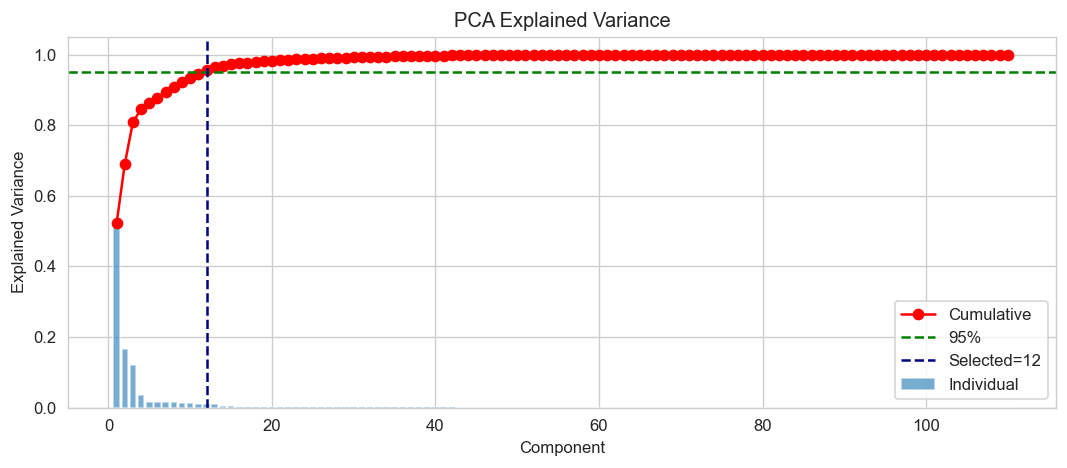

In [18]:
print('═' * 60)
print('STEP 2 — Relevance filter')
print('═' * 60)
_t1 = datetime.now()

selector.fit(X_tsfresh_train, y=y_tsfresh_train)
X_selected_train = selector.transform(X_tsfresh_train)
print(f'Selected features : {X_selected_train.shape[1]}')

print('\n' + '═' * 60)
print('STEP 3 — PCA')
print('═' * 60)

pca_step.fit(X_selected_train)
X_pca_train = pca_step.transform(X_selected_train)

print(f'PCA output shape  : {X_pca_train.shape}')
print(f'Total steps time  : {datetime.now() - _t1}')

# ── Plot explained variance using Matplotlib directly ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ev = pca_step.pca_.explained_variance_ratio_
cum = np.cumsum(ev)
n_selected = pca_step.n_selected_

ax.bar(range(1, len(ev)+1), ev, alpha=0.6, label='Individual')
ax.plot(range(1, len(ev)+1), cum, 'r-o', label='Cumulative')
ax.axhline(0.95, ls='--', color='green', label='95%')
ax.axvline(n_selected, ls='--', color='navy', label=f'Selected={n_selected}')

ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance')
ax.set_title('PCA Explained Variance')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_explained_variance.png', bbox_inches='tight')
plt.show()

# 6. Inference Pipeline: Validation on Unseen Data
In this cell, we apply our transformation pipeline to the Test Set. A critical best practice here is **not to refit** the `roller` or `pca_step`. We apply the *already learned* logic from the Training Set to the Testing Set. This simulates a "production environment" where the model receives data it has never seen before, allowing us to accurately benchmark how well our system generalizes to real-world engine degradation patterns.

In [ ]:
print('Transforming TEST set ...')
_t2 = datetime.now()

# 1. Roll (using the same roller fitted on train)
X_rolled_test  = roller.transform(test_scaled)

# 2. Extract (extractor is stateless — no fit needed)
X_tsfresh_test = extractor.transform(X_rolled_test)

# 3. Select & PCA (using the same fitted objects from train)
X_selected_test = selector.transform(X_tsfresh_test)
X_pca_test      = pca_step.transform(X_selected_test)

# 4. Keep only the LAST window per engine (the actual prediction point)
idx_frame = X_pca_test.index.to_frame(index=False)
idx_frame.columns = ['id', 'time_cycles'] 

last_pos = idx_frame.groupby('id')['time_cycles'].idxmax().values

X_pca_test_last = X_pca_test.iloc[last_pos].reset_index(drop=True)
y_test_true     = test_rul['rul'].to_numpy(dtype=float)

print(f'Test PCA (all windows) : {X_pca_test.shape}')
print(f'Test PCA (last cycle)  : {X_pca_test_last.shape}')
print(f'y_test_true            : {y_test_true.shape}')
print(f'Done in {datetime.now() - _t2}')

Transforming TEST set ...


Rolling:   0%|          | 0/303 [00:00<?, ?it/s]

Rolling: 100%|██████████| 303/303 [00:09<00:00, 32.11it/s] 


  Rolled shape: (359476, 13)
  Extracting TSFresh features ...


Feature Extraction: 100%|██████████| 144056/144056 [00:51<00:00, 2770.45it/s]


  Done 0:00:53.607117 — raw: (13096, 110)
    Dropped 0 duplicate columns
    Dropped 0 all-NaN columns
    Dropped 0 constant columns
  Clean shape: (13096, 110)
Test PCA (all windows) : (13096, 12)
Test PCA (last cycle)  : (100, 12)
y_test_true            : (100,)
Done in 0:01:03.511609


# 7. Artefact Serialization & Pipeline Deployment
We conclude the processing stage by saving our pipeline state as `.pkl` files. In industrial data science, the "model" is not just the algorithm; it is the entire chain of transformations. Saving these artefacts allows us to bypass the heavy computation of TSFresh/PCA in the future, enabling the deployment of this engine-monitoring system on edge devices where computational resources are limited.

In [21]:
print('Saving TSFresh artefacts ...')

save_pickle(X_pca_train,       OUTPUT_DIR / 'X_pca_train.pkl')
save_pickle(X_pca_test_last,   OUTPUT_DIR / 'X_pca_test.pkl')
save_pickle(y_tsfresh_train,   OUTPUT_DIR / 'y_tsfresh_train.npy')
save_pickle(y_test_true,       OUTPUT_DIR / 'y_test_true.npy')
save_pickle(selector,          OUTPUT_DIR / 'tsfresh_selector.pkl')
save_pickle(pca_step,          OUTPUT_DIR / 'pca_step.pkl')
save_pickle(tsfresh_pipeline,  OUTPUT_DIR / 'tsfresh_pipeline.pkl')

print('\n✅ All TSFresh artefacts saved.')
print('\n── Summary ──────────────────────────────────────────')
print(f'  Raw features     → {X_tsfresh_train.shape[1]}')
print(f'  After selection  → {X_selected_train.shape[1]}')
print(f'  After PCA        → {X_pca_train.shape[1]} components')
print(f'  Train samples    → {X_pca_train.shape[0]}')
print(f'  Test  samples    → {X_pca_test_last.shape[0]}')

Saving TSFresh artefacts ...
  ✅ Saved: outputs\X_pca_train.pkl
  ✅ Saved: outputs\X_pca_test.pkl
  ✅ Saved: outputs\y_tsfresh_train.npy
  ✅ Saved: outputs\y_test_true.npy
  ✅ Saved: outputs\tsfresh_selector.pkl
  ✅ Saved: outputs\pca_step.pkl
  ✅ Saved: outputs\tsfresh_pipeline.pkl

✅ All TSFresh artefacts saved.

── Summary ──────────────────────────────────────────
  Raw features     → 110
  After selection  → 110
  After PCA        → 12 components
  Train samples    → 20631
  Test  samples    → 100


# 8. Diagnostic Interpretability & Exploratory Analysis
Visualization is the bridge between complex mathematics and actionable insights.
- **PCA Analysis:** We visualize the latent space to see if the engine states are naturally clustering based on their RUL.
- **Feature Importance:** By analyzing the top features, we gain "Model Interpretability"—we can actually identify *which* sensors (e.g., Temperature, Pressure) are providing the most significant indicators of failure. This is often more important for maintenance engineers than the final prediction itself.

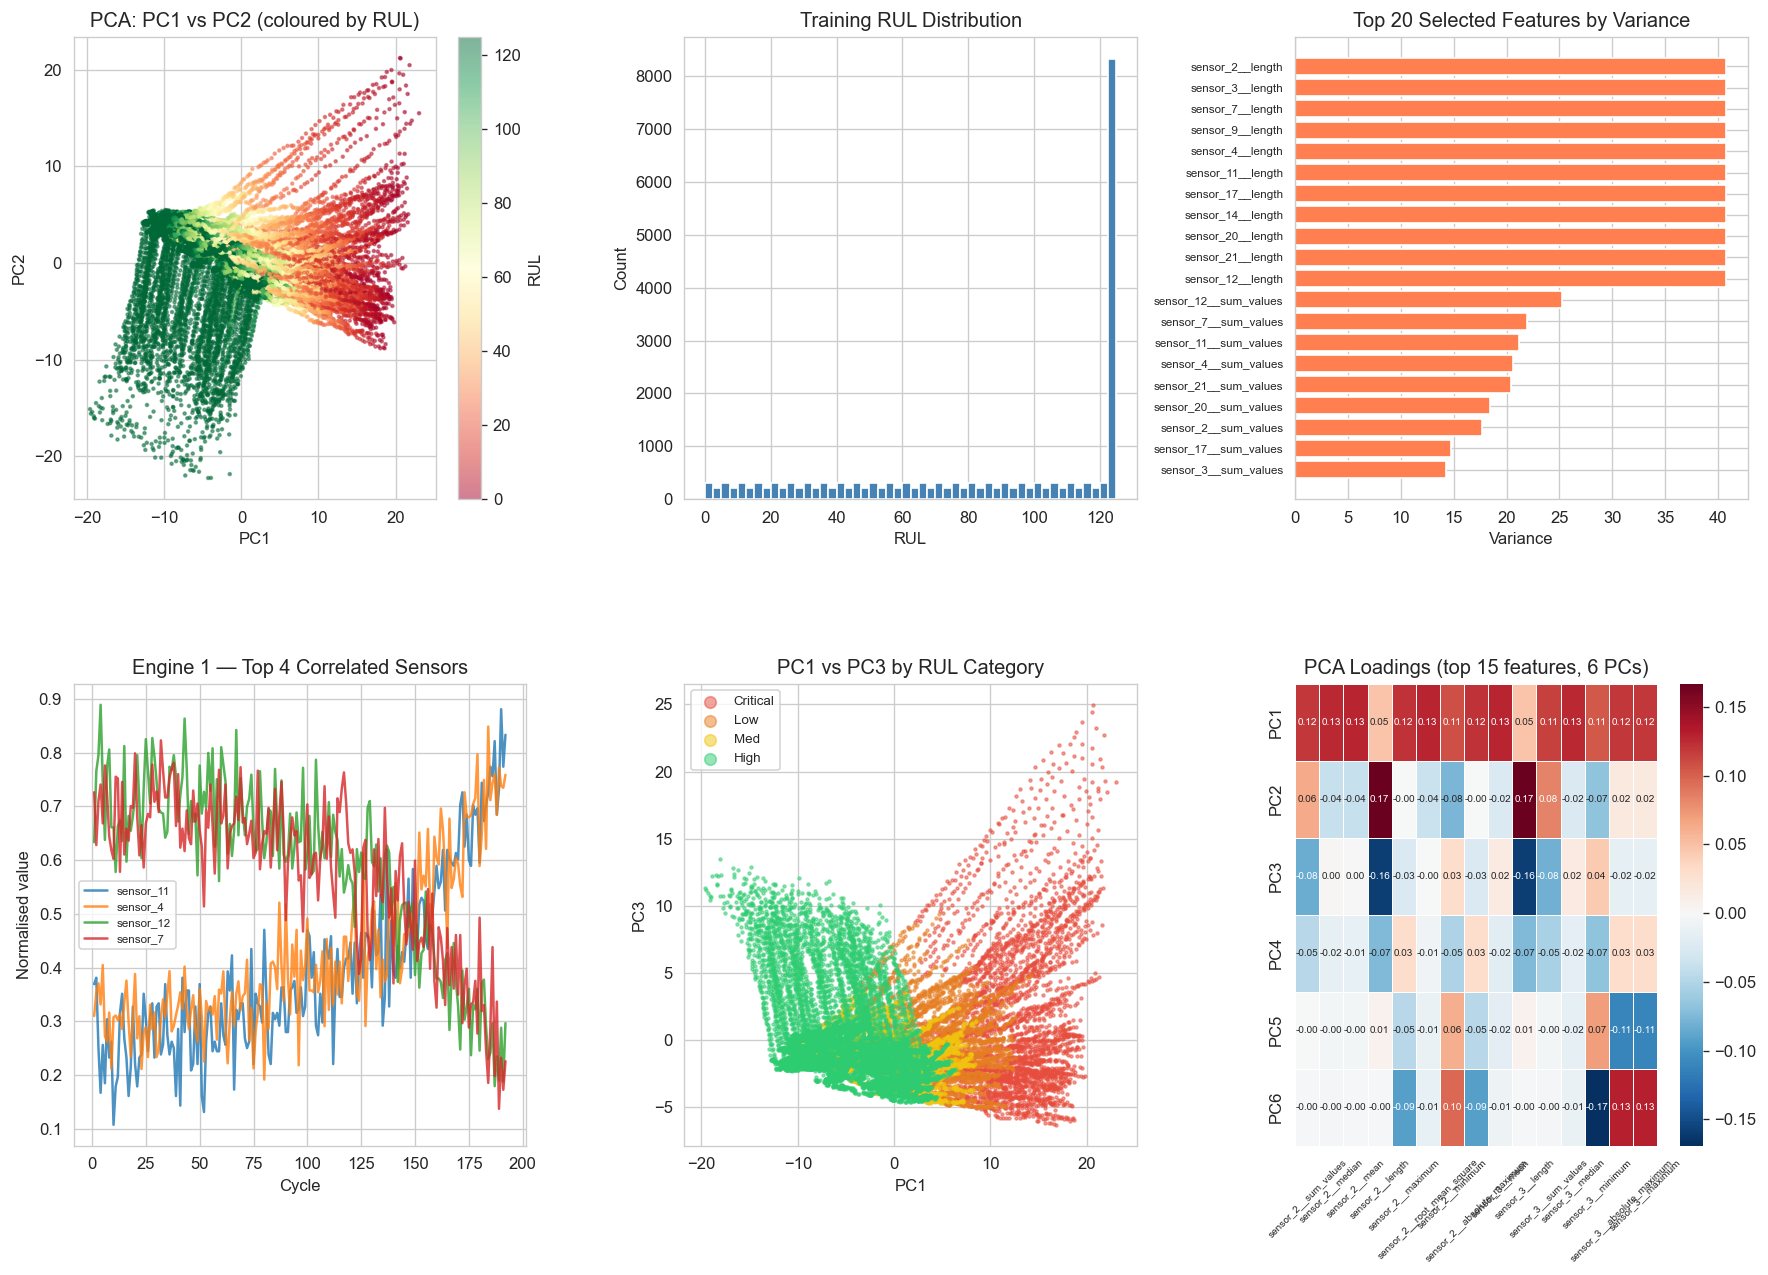

Figure saved → outputs/feature_engineering_summary.png


In [22]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. PC1 vs PC2 coloured by RUL ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sc  = ax1.scatter(
    X_pca_train.iloc[:, 0], X_pca_train.iloc[:, 1],
    c=y_tsfresh_train, cmap='RdYlGn', s=3, alpha=0.5
)
plt.colorbar(sc, ax=ax1, label='RUL')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
ax1.set_title('PCA: PC1 vs PC2 (coloured by RUL)')

# ── 2. RUL distribution ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(y_tsfresh_train, bins=50, edgecolor='white', color='steelblue')
ax2.set_xlabel('RUL'); ax2.set_ylabel('Count')
ax2.set_title('Training RUL Distribution')

# ── 3. Selected features bar (top 20 by TSFresh p-value) ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
n_show = min(20, X_selected_train.shape[1])
feat_var = X_selected_train.var().sort_values(ascending=False).head(n_show)
ax3.barh(feat_var.index[::-1], feat_var.values[::-1], color='coral')
ax3.set_xlabel('Variance')
ax3.set_title(f'Top {n_show} Selected Features by Variance')
ax3.tick_params(axis='y', labelsize=7)

# ── 4. Sensor time-series (engine 1) ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
eng1 = train_scaled[train_scaled['unit'] == 1]
top_sensors = corr_df['correlation_with_RUL'].abs().head(4).index.tolist()
for s in top_sensors:
    if s in eng1.columns:
        ax4.plot(eng1['time_cycles'], eng1[s], label=s, alpha=0.8)
ax4.set_xlabel('Cycle'); ax4.set_ylabel('Normalised value')
ax4.set_title('Engine 1 — Top 4 Correlated Sensors')
ax4.legend(fontsize=7)

# ── 5. Pairplot of first 3 PCs vs RUL bin ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
rul_bin = pd.cut(y_tsfresh_train, bins=4, labels=['Critical','Low','Med','High'])
for label, colour in zip(['Critical','Low','Med','High'],
                          ['#e74c3c','#e67e22','#f1c40f','#2ecc71']):
    mask = rul_bin == label
    ax5.scatter(
        X_pca_train.iloc[mask, 0],
        X_pca_train.iloc[mask, 2] if X_pca_train.shape[1] > 2 else X_pca_train.iloc[mask, 1],
        label=label, s=3, alpha=0.5, color=colour
    )
ax5.set_xlabel('PC1')
ax5.set_ylabel('PC3' if X_pca_train.shape[1] > 2 else 'PC2')
ax5.set_title('PC1 vs PC3 by RUL Category')
ax5.legend(markerscale=4, fontsize=8)

# ── 6. PCA component heatmap ──────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
n_feat_show = min(15, len(selector.relevant_features_))
n_pc_show   = min(6,  pca_step.n_selected_)
loadings    = pd.DataFrame(
    pca_step.pca_.components_[:n_pc_show, :n_feat_show],
    columns=selector.relevant_features_[:n_feat_show],
    index=[f'PC{i+1}' for i in range(n_pc_show)]
)
sns.heatmap(loadings, ax=ax6, cmap='RdBu_r', center=0,
            linewidths=0.3, annot=True, fmt='.2f', annot_kws={'size': 6})
ax6.set_title(f'PCA Loadings (top {n_feat_show} features, {n_pc_show} PCs)')
ax6.tick_params(axis='x', labelsize=6, rotation=45)

plt.savefig(OUTPUT_DIR / 'feature_engineering_summary.png', bbox_inches='tight')
plt.show()
print(f'Figure saved → {OUTPUT_DIR}/feature_engineering_summary.png')

# 9. Establishing the Performance Baseline
To determine the success of our feature engineering, we utilize Ridge Regression as our benchmark. 
- **Why Ridge?** It penalizes large coefficients (L2 Regularization), preventing the model from becoming overly sensitive to any single sensor.
- **Benchmarking:** By calculating the RMSE and MAE, we quantify our model's accuracy. This creates a "baseline" performance. Any future development—like transitioning to a Deep Neural Network—will be measured against these specific scores to prove the value of those more complex architectures.

Ridge 5-fold CV RMSE: 21.96 ± 0.83

── Test Set Results (Ridge baseline) ──
  RMSE  : 22.581772582694086
  MAE   : 18.682198415984963
  MAPE  : 45.4321403310293
  SCORE : 1388.906392803802


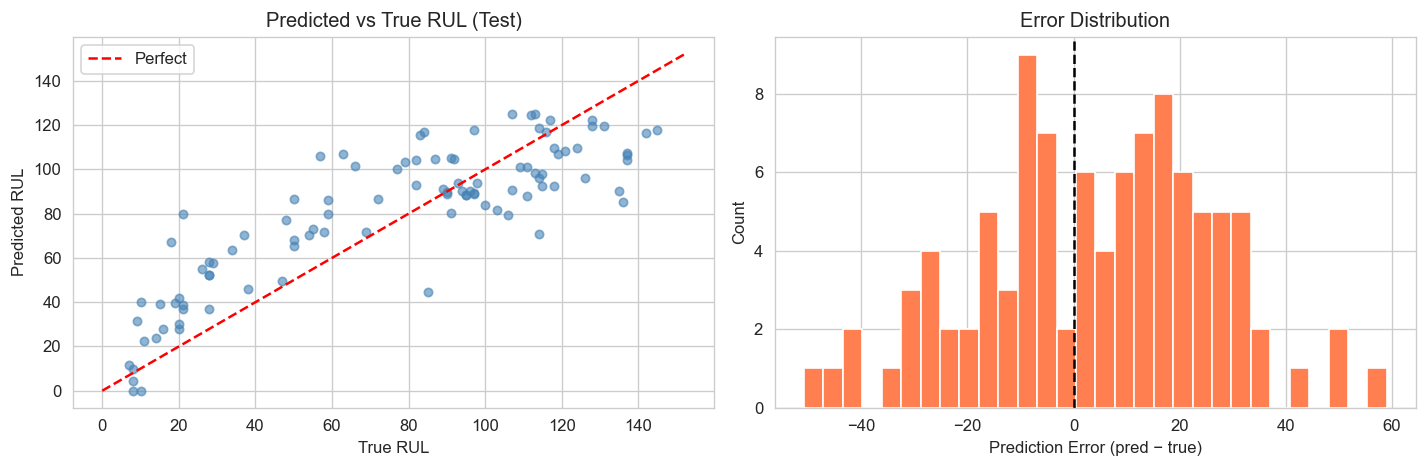


🎯 Feature engineering complete!
   Ready artefacts for model training:
   · X_pca_train / y_tsfresh_train  — TSFresh + PCA train features + labels
   · X_pca_test_last / y_test_true  — TSFresh + PCA test features + true RUL
   · X_train_seq / X_test_seq       — raw windowed sequences (for LSTM etc.)
   All saved to: D:\DEPI\Project Git\Yaqza\ml\notebooks\outputs


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Simple Ridge regression on PCA features as a sanity baseline.
# Replace with your own model in the next notebook.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_pca_train, y_tsfresh_train)

# CV RMSE on train
cv_rmse = -cross_val_score(
    ridge, X_pca_train, y_tsfresh_train,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
print(f'Ridge 5-fold CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}')

# Test evaluation
pred_test = ridge.predict(X_pca_test_last)
pred_test = np.clip(pred_test, 0, RUL_UPPER_THRESHOLD)  # RUL ≥ 0

results = {}
for k, fn in SCORE_FUNCTIONS.items():
    try:
        results[k] = fn(y_test_true, pred_test)
    except Exception as e:
        results[k] = f'error: {e}'

print('\n── Test Set Results (Ridge baseline) ──')
for k, v in results.items():
    print(f'  {k.upper():6s}: {v}')

# ── Pred vs True plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test_true, pred_test, alpha=0.6, s=25, color='steelblue')
lim = max(y_test_true.max(), pred_test.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('True RUL'); axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('Predicted vs True RUL (Test)')
axes[0].legend()

errors = pred_test - y_test_true
axes[1].hist(errors, bins=30, edgecolor='white', color='coral')
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Prediction Error (pred − true)')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_results.png', bbox_inches='tight')
plt.show()

print('\n🎯 Feature engineering complete!')
print('   Ready artefacts for model training:')
print('   · X_pca_train / y_tsfresh_train  — TSFresh + PCA train features + labels')
print('   · X_pca_test_last / y_test_true  — TSFresh + PCA test features + true RUL')
print('   · X_train_seq / X_test_seq       — raw windowed sequences (for LSTM etc.)')
print('   All saved to:', OUTPUT_DIR.resolve())

Note that here we end up with `p >> n` case.

---